# **Aprendizado de Máquina** <BR> **Aula 05** - Classificação multiclasse e classificador *KNN*

# **Exemplo 1**. Classificação por regressão logística no *dataset Iris*.

## **1)** Importação de bibliotecas e classes

In [ ]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Bibliotecas específicas de Machine Learning
from sklearn.linear_model import LogisticRegression   # Classificador por regressão logística

from sklearn.model_selection import train_test_split  # Divisão de dados para validação cruzada hold-out
from sklearn.model_selection import cross_val_score   # Validação cruzada k-folds

from sklearn.metrics import accuracy_score, classification_report   # Métricas de qualidade
from sklearn.metrics import ConfusionMatrixDisplay    # Visualização "gráfica" da matriz de confusão

## **2)** Leitura de dados e exploração inicial

In [ ]:
# Leitura do arquivo de dados e exibição do DataFrame
# ATENÇÃO: "monte" o disco e ajuste o caminho do arquivo de dados!
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/Ciência de Dados e Inteligência Artificial/Aprendizado de Maquina/Datasets/A05EXEMPLO1_iris.csv"

df = pd.read_csv(caminho_arquivo)
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,Virginica
146,6.3,2.5,5.0,1.9,2,Virginica
147,6.5,3.0,5.2,2.0,2,Virginica
148,6.2,3.4,5.4,2.3,2,Virginica


### **2.1)** Características gerais

In [ ]:
# Contagem de classes da resposta/target
df['species'].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,50


### **2.2)** Gráficos

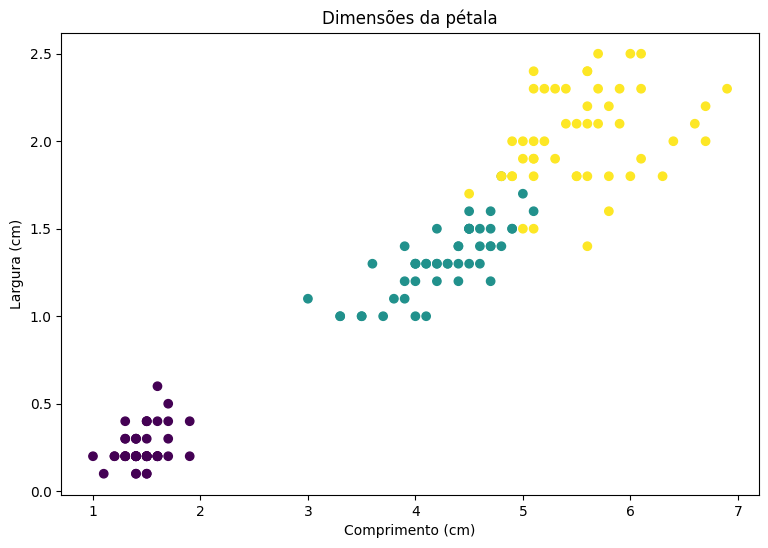

In [ ]:
# Diagrama de dispersão entre comprimento e largura da pétala
plt.figure(figsize = (9,6))   # Define largura e altura (em polegadas)
plt.scatter(x = df['petal length (cm)'],y = df['petal width (cm)'],c = df['target'])
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")
plt.show()    # "Consolida" a exibição do gráfico

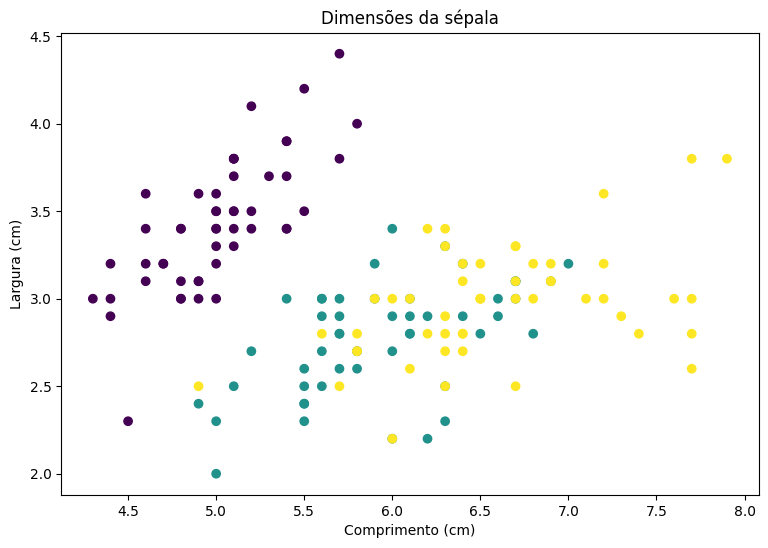

In [ ]:
# Diagrama de dispersão entre comprimento e largura da sépala
plt.figure(figsize = (9,6))   # Define largura e altura (em polegadas)
plt.scatter(x = df['sepal length (cm)'],y = df['sepal width (cm)'],c = df['target'])
plt.title("Dimensões da sépala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")
plt.show()    # "Consolida" a exibição do gráfico

## **3)** Seleção e pré-processamento de atributos

In [ ]:
# Recordando os nomes das colunas do DataFrame
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

In [ ]:
X = df.drop(columns = ['target','species'])   # Atributos: 4 dimensões das flores
y = df['species']                             # Reposta: espécie. Opção: df['target']

In [ ]:
# Pré-processamento 1: divisão em dados de treino (80%) e teste (20%)
# IMPORTANTE: sem o controle do parâmetro 'random_state', diferentes partições
# do conjunto de dados serão retornadas a cada execução da função de divisão
# o stratify divide igualmente as classes de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8,
                                                        random_state = 42,
                                                        stratify = y)

In [ ]:
# Dimensões
print("Dimensões dos dados de treino:",X_treino.shape)
print("Dimensões dos dados de teste:",X_teste.shape)

Dimensões dos dados de treino: (120, 4)
Dimensões dos dados de teste: (30, 4)


In [ ]:
# Contagens de classes (para conferência)
print("Classes dos dados de treino:", y_treino.value_counts())
print("")   # "imprime" uma linha em branco
print("Classes dos dados de teste:", y_teste.value_counts())

Classes dos dados de treino: species
Setosa        40
Virginica     40
Versicolor    40
Name: count, dtype: int64

Classes dos dados de teste: species
Setosa        10
Virginica     10
Versicolor    10
Name: count, dtype: int64


## **4)** Treinamento do classificador por regressão logística

In [ ]:
# Observar o total de iterações do algoritmo de treinamento (valor da
# propriedade 'n_iter_') e, se necessário, ajustar o valor de 'max_iter'
clf_RL = LogisticRegression()
clf_RL.fit(X_treino,y_treino)

print("Iterações do algoritmo de treino:",clf_RL.n_iter_)

Iterações do algoritmo de treino: [72]


In [ ]:
# Pré-processamento 2: PADRONIZAÇÃO dos atributos (treino e
# teste) segundo a média e desvio padrão DO CONJUNTO DE TREINO

# Importação da biblioteca de padronização de atributos
from sklearn.preprocessing import StandardScaler

# Criação de instância e treinamento de um objeto "escalonador"
escalonador = StandardScaler()
escalonador.fit(X_treino)

# Padronização dos dados de treino e teste
X_treino_Padr = escalonador.transform(X_treino)
X_teste_Padr = escalonador.transform(X_teste)

In [ ]:
# Conversão dos conjuntos padronizados em DataFrames
X_treino_Padr = pd.DataFrame(data = X_treino_Padr,columns = X_treino.columns)
X_teste_Padr = pd.DataFrame(data = X_teste_Padr,columns = X_treino.columns)

In [ ]:
# Exibição dos dados de treino padronizados
X_treino_Padr

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-1.721568,-0.332101,-1.345722,-1.323276
1,-1.124492,-1.227655,0.414505,0.651763
2,1.144395,-0.555990,0.584850,0.256755
3,-1.124492,0.115676,-1.288941,-1.454945
4,-0.408002,-1.227655,0.130598,0.125086
...,...,...,...,...
115,-1.124492,1.235118,-1.345722,-1.454945
116,-1.363322,0.339564,-1.402504,-1.323276
117,-0.408002,2.578448,-1.345722,-1.323276
118,1.263810,0.115676,0.641631,0.388424


In [ ]:
# Resumo estatístico dos dados de treino padronizados: observe
# as informações de média (mean) e desvio padrão (std)
X_treino_Padr.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02
mean,-1.369275e-16,9.992007e-16,1.665335e-17,1.702342e-16
std,1.004193e+00,1.004193e+00,1.004193e+00,1.004193e+00
min,-1.840983e+00,-2.347097e+00,-1.516067e+00,-1.454945e+00
25%,-8.856620e-01,-5.559895e-01,-1.232159e+00,-1.191606e+00
50%,-1.094638e-01,-1.082127e-01,2.725514e-01,1.250858e-01
75%,6.667343e-01,6.194245e-01,7.551944e-01,7.834318e-01
max,2.457961e+00,3.026225e+00,1.777262e+00,1.705116e+00


In [ ]:
# Treinamento do classificador por regressão logística com DADOS PADRONIZADOS
clf_RL = LogisticRegression()
clf_RL.fit(X_treino_Padr,y_treino)

print("Iterações do algoritmo de treino:",clf_RL.n_iter_)

Iterações do algoritmo de treino: [16]


## **5)** Validação cruzada *hold-out*

In [ ]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_RL.predict(X_teste_Padr)

# Cálculo da acurácia (nos dados de teste)
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.9333333333333333


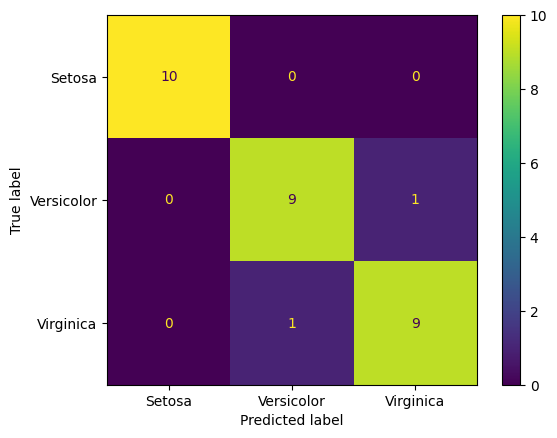

In [ ]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.show()

In [ ]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

      Setosa     1.0000    1.0000    1.0000        10
  Versicolor     0.9000    0.9000    0.9000        10
   Virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



## **6)** Validação cruzada *k-folds*

In [ ]:
# Validação cruzada k-folds (com k = 10), avaliando a ACURÁCIA
# Padronização do conjunto COMPLETO de atributos
X_Padr = escalonador.transform(X)

aval = cross_val_score(clf_RL,X_Padr,y,cv = 10,scoring = 'accuracy')
M = aval.mean()     # Média das avaliações
DP = aval.std()     # Desvio padrão das avaliações
CV_aval = 100*DP/M  # Coeficiente de variação (%) das avaliações

print("Acurácias obtidas:",aval)
print("")   # "Imprime" uma linha em branco
print("Acurácia média =",M)
print("Coeficiente de variação (%) =",CV_aval)

Acurácias obtidas: [1.         0.93333333 1.         1.         0.93333333 0.93333333
 0.8        1.         1.         1.        ]

Acurácia média = 0.9600000000000002
Coeficiente de variação (%) = 6.3646884652164415


---
**Fim do Exemplo 1 da Aula 05**